# Assignment 1: Image Representation and Visual Exploration

**Individual · 75 points**

This assignment asks one connected question: **how does representation change what we see, compute, and communicate?** Complete the important array operations in `src/student_code.py`; use the provided helpers only for paths, plotting layout, asset integrity, and portable video I/O.

## 0. Student Information

- First name: **Samantha**
- Last name: **Salas**
- ABC123: **xso947**
- External resources and generative-AI assistance: **Claude Code**

This is an individual assignment. Do not install unapproved packages or use external libraries or pretrained pipelines to bypass a required implementation.

Generative AI tools may be used for conceptual clarification, debugging assistance, code suggestions, and help interpreting documentation. Students must disclose meaningful use in every assignment. You remain responsible for understanding, testing, and explaining all submitted work. AI may not replace your own experimental analysis, failure analysis, reflection, or interpretation of observed results. You may be asked to explain selected work; inability to do so may reduce credit or lead to an academic-integrity review.


## 1. Assignment Overview and Learning Objectives

By completing A1, you should be able to load, inspect, display, save, and manipulate image arrays; reason about shape, channel order, dtype, and range; compare grayscale/RGB/BGR/HSV representations; perform controlled experiments; and read, sample, transform, write, and verify video.

**Point map:** core implementation 30; required experiments 19; results/analysis/failure reasoning 15; reproducibility/submission 7; extension 4.

| Tables & Metadata | Figures | Other Outputs |
|---|---|---|
| `image_metadata.csv` | `image_overview.png` | `a1_transformed.mp4` |
| `timing.csv` | `numpy_manipulations.png` | one declared extension artifact |
| `experiment_metrics.csv` | `dtype_range_experiment.png` | |
| `video_metadata.json` | `color_representations.png` | |
| | `hsv_stability.png` | |
| | `video_contact_sheet.png` | |
| | `failure_image.png`, `failure_video.png` | |


## 2. Environment Verification

Run this cell first. It discovers the repository from the installed course package rather than the terminal working directory. A clean checksum list is required. If it fails, run the A1 preflight command from the README.


In [2]:
from pathlib import Path
import json, sys, time
import cv2
import imageio.v3 as iio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import cs5243
from cs5243.data import find_course_root
COURSE_ROOT = find_course_root(Path(cs5243.__file__))
A1 = COURSE_ROOT / "A1"
sys.path.insert(0, str(A1 / "src"))
import a1_tools
import student_code as sc
PATHS = a1_tools.ensure_output_directories()
assert a1_tools.verify_asset_hashes() == []
print({"assignment": "A1-2026.1", "environment": "2026.1"})


{'assignment': 'A1-2026.1', 'environment': '2026.1'}


## 3. Dataset and Problem Setup

The course-staff-generated CC0 dataset contains strong channel-order cues, aligned illumination variants, uint16 intensities, different aspect ratios, and a four-second MP4. Do not move or edit assets.

### Task 1 — inspect and communicate image arrays (6 points)

Implement `image_summary`. Load each image without silently discarding its native dtype. Save `outputs/tables/image_metadata.csv` with filename, shape, height, width, channels, dtype, minimum, maximum, mean, and bytes. Inspect at least three named pixels, including a channel-order swatch. Save a captioned overview as `outputs/figures/image_overview.png`. Explain immediately below what shape order means and how the array represents a pixel.

Implement reusable graded functions in `src/student_code.py`; use the notebook to call those functions, conduct experiments, save required artifacts, and explain the results.


wrote /home/sqmi/CS-5243-Computer-Vision/CS-5243-Computer-Vision/A1/outputs/tables/image_metadata.csv


,filename,shape,height,width,channels,dtype,minimum,maximum,mean,bytes
0,channel_order.png,"(300, 720, 3)",300,720,3,uint8,35,255,86.4728,648000
1,color_shapes.png,"(400, 640, 3)",400,640,3,uint8,30,245,179.6837,768000
2,color_shapes_dim.png,"(400, 640, 3)",400,640,3,uint8,16,121,100.2257,768000
3,color_shapes_warm.png,"(400, 640, 3)",400,640,3,uint8,7,255,165.4735,768000
4,intensity_ramp_16bit.png,"(256, 512)",256,512,1,uint16,0,65535,23065.5137,262144
5,portrait_scene.png,"(540, 360, 3)",540,360,3,uint8,35,240,190.9281,583200
6,wide_scene.jpg,"(300, 720, 3)",300,720,3,uint8,0,255,162.1579,648000


channel_order.png RED block  (row 150, col 120): array value (R, G, B) = (235, 35, 35)
channel_order.png GREEN block (row 150, col 360): array value (R, G, B) = (35, 210, 65)
channel_order.png BLUE block  (row 150, col 600): array value (R, G, B) = (40, 90, 240)
wrote /home/sqmi/CS-5243-Computer-Vision/CS-5243-Computer-Vision/A1/outputs/figures/image_overview.png


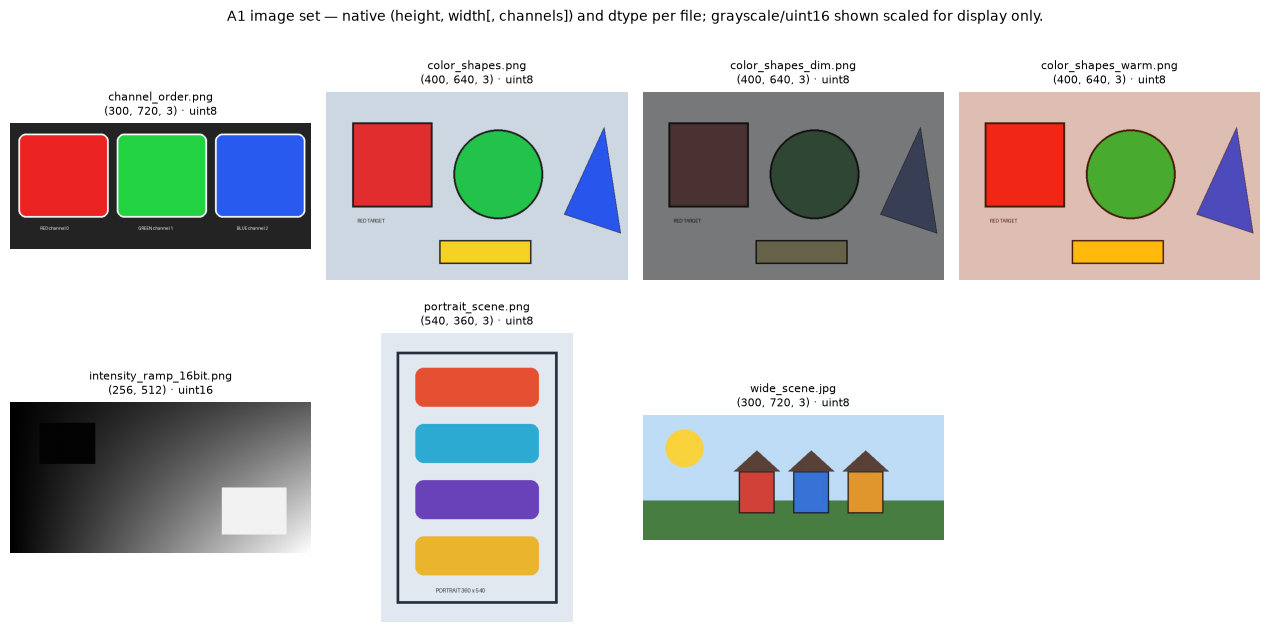

In [3]:
# STUDENT WORK — Task 1
image_paths = a1_tools.discover_images()

# Load, summarize, save image_metadata.csv, and create image_overview.png.
loaded, records = {}, []
for path in image_paths:
    array = iio.imread(path)
    loaded[path.name] = array
    s = sc.image_summary(array)
    low, high = s["range"]
    records.append({
        "filename": path.name, "shape": s["shape"], "height": s["height"],
        "width": s["width"], "channels": s["channels"], "dtype": s["dtype"],
        "minimum": low, "maximum": high, "mean": round(s["mean"], 4), "bytes": s["nbytes"],
    })

metadata = pd.DataFrame.from_records(records)
csv_path = PATHS["tables"] / "image_metadata.csv"
metadata.to_csv(csv_path, index=False)
print("wrote", csv_path)
display(metadata)

# --- three named pixels: a channel-order swatch across channel_order.png ---
co = loaded["channel_order.png"]
named_pixels = {
    "channel_order.png RED block  (row 150, col 120)": co[150, 120],
    "channel_order.png GREEN block (row 150, col 360)": co[150, 360],
    "channel_order.png BLUE block  (row 150, col 600)": co[150, 600],
}
for label, value in named_pixels.items():
    print(f"{label}: array value (R, G, B) = {tuple(int(c) for c in value[:3])}")

# --- captioned overview figure ---
cols = 4
rows = (len(image_paths) + cols - 1) // cols
fig, axes = a1_tools.axes_grid(rows, cols)
for ax in axes.flat:
    ax.axis("off")
for ax, path in zip(axes.flat, image_paths):
    a = loaded[path.name]
    if a.ndim == 2:  # grayscale / uint16: scale to [0, 1] for display only
        ax.imshow(a, cmap="gray", vmin=0, vmax=np.iinfo(a.dtype).max)
    else:
        ax.imshow(a[..., :3])
    ax.set_title(f"{path.name}\n{a.shape} · {a.dtype}", fontsize=8)
fig.suptitle("A1 image set — native (height, width[, channels]) and dtype per file; "
            "grayscale/uint16 shown scaled for display only.", fontsize=10)
fig.tight_layout()
overview_path = PATHS["figures"] / "image_overview.png"
fig.savefig(overview_path, dpi=150, bbox_inches="tight")
print("wrote", overview_path)
plt.show()

#raise NotImplementedError("Complete Task 1")


**Task 1 analysis (3–5 sentences):** YOUR RESPONSE. Cite array values and distinguish `(height, width, channels)` from `(width, height)`.


Shape order given by (height, width, channels) compared to (width, height) boils down to how the x and y values are interpreted. For instance, channel_order.png and wide_scene.jpg have the shape (300, 720, 3). The form (height, width, channels) takes on the simplified version of (y, x, [R, G, B]). In channel_order.png, an array value is (235, 35, 35) at (row 150, column 120) representing the color of that specific pixel which is red-dominant. This differs from the (width, height) (or (x, y)) shape order since these numbers represents the size of an image (e.g. 1920 x 1080).

## 4. Core Implementation

### Task 2 — NumPy spatial/channel operations (11 points)

Implement crop, horizontal flip, channel extraction/reordering, rectangular replacement, and contact-sheet construction using NumPy. Crops and replacements must be positive, in bounds, and non-mutating. A contact-sheet call must contain either all grayscale or all RGB `uint8` images; top-left-align them with an 8-pixel outer border and gutter. Make one coherent comparison using `channel_order.png`, `portrait_scene.png`, and `wide_scene.jpg`. Do not use OpenCV functions that directly perform these graded operations. Save `outputs/figures/numpy_manipulations.png` with a descriptive caption.


wrote /home/sqmi/CS-5243-Computer-Vision/CS-5243-Computer-Vision/A1/outputs/figures/numpy_manipulations.png


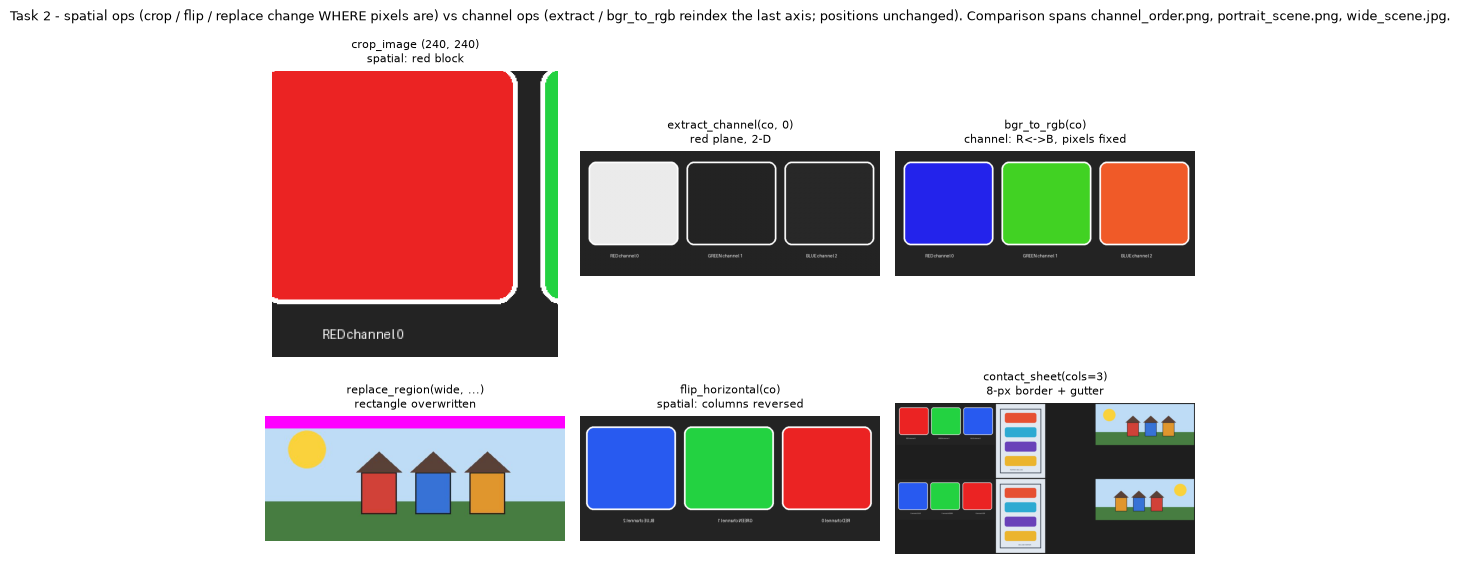

In [4]:
# STUDENT WORK — Task 2
# Demonstrate each implementation and save numpy_manipulations.png.
paths = {p.name: p for p in a1_tools.discover_images()}
co       = iio.imread(paths["channel_order.png"])
portrait = iio.imread(paths["portrait_scene.png"])
wide     = iio.imread(paths["wide_scene.jpg"])

# --- individual operations ---
crop      = sc.crop_image(co, top=30, left=30, height=240, width=240)   # spatial: the RED block
red_plane = sc.extract_channel(co, 0)                                   # channel: 2-D red plane
swapped   = sc.bgr_to_rgb(co)                                           # channel: reverse last axis
flipped   = sc.flip_horizontal(co)                                      # spatial: reverse columns
banner    = sc.replace_region(wide, 0, 0, 30, wide.shape[1], (255, 0, 255))  # overwrite a rectangle

# --- non-mutation check ---
before = iio.imread(paths["channel_order.png"])
for _ in (sc.crop_image(co, 0, 0, 10, 10), sc.flip_horizontal(co),
        sc.bgr_to_rgb(co), sc.replace_region(co, 0, 0, 10, 10, 0)):
  pass
assert np.array_equal(co, before), "a Task 2 op mutated its input"

# --- one coherent comparison across all three images ---
gallery = sc.contact_sheet(
  [co, portrait, wide,
   sc.flip_horizontal(co), sc.flip_horizontal(portrait), sc.flip_horizontal(wide)],
  columns=3, fill_value=30,
)

fig, axes = a1_tools.axes_grid(2, 3)
for ax in axes.flat:
  ax.axis("off")
axes[0, 0].imshow(crop);      axes[0, 0].set_title(f"crop_image {crop.shape[:2]}\nspatial: red block", fontsize=8)
axes[0, 1].imshow(red_plane, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("extract_channel(co, 0)\nred plane, 2-D", fontsize=8)
axes[0, 2].imshow(swapped);   axes[0, 2].set_title("bgr_to_rgb(co)\nchannel: R<->B, pixels fixed", fontsize=8)
axes[1, 0].imshow(banner);    axes[1, 0].set_title("replace_region(wide, ...)\nrectangle overwritten", fontsize=8)
axes[1, 1].imshow(flipped);   axes[1, 1].set_title("flip_horizontal(co)\nspatial: columns reversed", fontsize=8)
axes[1, 2].imshow(gallery);   axes[1, 2].set_title("contact_sheet(cols=3)\n8-px border + gutter", fontsize=8)
fig.suptitle("Task 2 - spatial ops (crop / flip / replace change WHERE pixels are) vs "
           "channel ops (extract / bgr_to_rgb reindex the last axis; positions unchanged). "
           "Comparison spans channel_order.png, portrait_scene.png, wide_scene.jpg.", fontsize=9)
fig.tight_layout()
out = PATHS["figures"] / "numpy_manipulations.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print("wrote", out)
plt.show()
# raise NotImplementedError("Complete Task 2")


**Task 2 analysis (2–4 sentences):** YOUR RESPONSE. Identify what was reordered versus what changed spatially.

# TODO: WRITE ANALYSIS



### Task 3 — loop and vectorized arithmetic (6 points)

Implement `brighten_loop` and `brighten_vectorized` using `np.rint` nearest-even rounding before clipping to `[0, 255]` and conversion to `uint8`. Time each at least three times on the same image using `time.perf_counter`; report median milliseconds, repeat count, and output equality in `outputs/tables/timing.csv`. Timing supports a representation argument; it is not a benchmarking contest.


In [5]:
# STUDENT WORK — Task 3
# Controlled comparison: same image, same offset, same rounding-and-clipping rule for both
# implementations, so the only thing that varies is the loop-versus-array-op strategy.
paths = {p.name: p for p in a1_tools.discover_images()}
source = iio.imread(paths["wide_scene.jpg"])          # one fixed uint8 RGB image
OFFSET, REPEATS = 40, 5
print(f"timing on wide_scene.jpg {source.shape} {source.dtype} "
      f"({source.size:,} elements), offset=+{OFFSET}, repeats={REPEATS}")


def time_call(function, image, offset, repeats):
    """Call function(image, offset) `repeats` times; return the last result and elapsed ms."""
    samples, result = [], None
    for _ in range(repeats):
        start = time.perf_counter()
        result = function(image, offset)
        samples.append((time.perf_counter() - start) * 1000.0)
    return result, samples


loop_out, loop_ms = time_call(sc.brighten_loop, source, OFFSET, REPEATS)
vector_out, vector_ms = time_call(sc.brighten_vectorized, source, OFFSET, REPEATS)

identical = bool(np.array_equal(loop_out, vector_out))
assert identical, "brighten_loop and brighten_vectorized disagree"
loop_median = float(np.median(loop_ms))
vector_median = float(np.median(vector_ms))


def timing_row(name, samples):
    """One CSV row: median/min/max milliseconds plus the controlled conditions."""
    return {
        "method": name, "image": "wide_scene.jpg", "shape": str(source.shape),
        "elements": int(source.size), "offset": OFFSET, "repeats": REPEATS,
        "median_ms": round(float(np.median(samples)), 4),
        "min_ms": round(min(samples), 4), "max_ms": round(max(samples), 4),
        "outputs_equal": identical,
        "speedup_vs_loop": round(loop_median / float(np.median(samples)), 2),
    }


timing = pd.DataFrame([timing_row("brighten_loop", loop_ms),
                       timing_row("brighten_vectorized", vector_ms)])
timing_path = PATHS["tables"] / "timing.csv"
timing.to_csv(timing_path, index=False)
print("wrote", timing_path)
display(timing)

# --- what the timing is an argument about: both paths share one representation rule ---
probe = np.array([[0, 10, 250]], dtype=np.uint8)
print("\nprobe uint8               :", probe.tolist())
print("brighten_loop(+20)        :", sc.brighten_loop(probe, 20).tolist())
print("brighten_vectorized(+20)  :", sc.brighten_vectorized(probe, 20).tolist())
print("naive uint8 add (+20)     :", (probe + np.uint8(20)).tolist(), "<- 250 wraps to 14")
print(f"\nmedian of {REPEATS} repeats: loop {loop_median:.2f} ms vs vectorized "
      f"{vector_median:.3f} ms = {loop_median / vector_median:.1f}x; "
      f"outputs identical: {identical}")

timing on wide_scene.jpg (300, 720, 3) uint8 (648,000 elements), offset=+40, repeats=5
wrote /home/sqmi/CS-5243-Computer-Vision/CS-5243-Computer-Vision/A1/outputs/tables/timing.csv


,method,image,shape,elements,offset,repeats,median_ms,min_ms,max_ms,outputs_equal,speedup_vs_loop
0,brighten_loop,wide_scene.jpg,"(300, 720, 3)",648000,40,5,232.9406,224.3183,270.4486,True,1.00
1,brighten_vectorized,wide_scene.jpg,"(300, 720, 3)",648000,40,5,3.0683,2.3551,3.6613,True,75.92



probe uint8               : [[0, 10, 250]]
brighten_loop(+20)        : [[20, 30, 255]]
brighten_vectorized(+20)  : [[20, 30, 255]]
naive uint8 add (+20)     : [[20, 30, 14]] <- 250 wraps to 14

median of 5 repeats: loop 232.94 ms vs vectorized 3.068 ms = 75.9x; outputs identical: True


**Task 3 analysis (2–3 sentences):** YOUR RESPONSE. Report the measured ratio and explain why the comparison is controlled.

# TODO: WRITE ANALYSIS



### Task 4 — datatype/range safety (7 points)

Implement `to_float01` and `to_uint8_safe`. Diagnose and repair this deliberately incorrect conversion:

```python
wrong = (float_image * 255).astype(np.uint8)  # no range check; truncates and wraps
```

Compare uint8 addition with float addition, include the uint16 ramp, and save `outputs/figures/dtype_range_experiment.png`. Record at least three quantitative comparisons in `outputs/tables/experiment_metrics.csv`.

Analyze uint8 overflow and float-to-uint8 conversion as two distinct failure mechanisms.


scene  (300, 720, 3) uint8 range 0-255
ramp16 (256, 512) uint16 range 0-65535

to_float01 dtype=float32 range 0.0000-1.0000; round-trip max |error| = 0
uint8 +80: 58.57% of samples wrapped to a DARKER value; largest disagreement with the float path = 255
float gain x1.4: 58.49% of samples exceed 1.0; the unchecked cast disagrees with to_uint8_safe on 62.89% of samples (max gap 255)
uint16 ramp: rescaled row monotonic = True; naive .astype(uint8) row monotonic = False (the low byte sawtooths 173 times)
wrote /home/sqmi/CS-5243-Computer-Vision/CS-5243-Computer-Vision/A1/outputs/tables/experiment_metrics.csv


,experiment,method,condition,metric,value,units
15,task4-dtype-range,to_float01 -> to_uint8_safe,wide_scene.jpg uint8,max absolute round-trip error,0.000000,levels
16,task4-dtype-range,uint8 addition,wide_scene.jpg +80,fraction of samples wrapped darker,0.585707,fraction
17,task4-dtype-range,float addition + to_uint8_safe,wide_scene.jpg +80,max disagreement with uint8 addition,255.000000,levels
18,task4-dtype-range,(float*255).astype(uint8),wide_scene.jpg gain x1.4,fraction of samples disagreeing with to_uint8_...,0.628897,fraction
19,task4-dtype-range,(float*255).astype(uint8),wide_scene.jpg gain x1.4,max disagreement with to_uint8_safe,255.000000,levels
20,task4-dtype-range,uint16 .astype(uint8),intensity_ramp_16bit.png,monotonic across the middle row,0.000000,boolean
21,task4-dtype-range,to_float01 -> to_uint8_safe,intensity_ramp_16bit.png,monotonic across the middle row,1.000000,boolean


wrote /home/sqmi/CS-5243-Computer-Vision/CS-5243-Computer-Vision/A1/outputs/figures/dtype_range_experiment.png


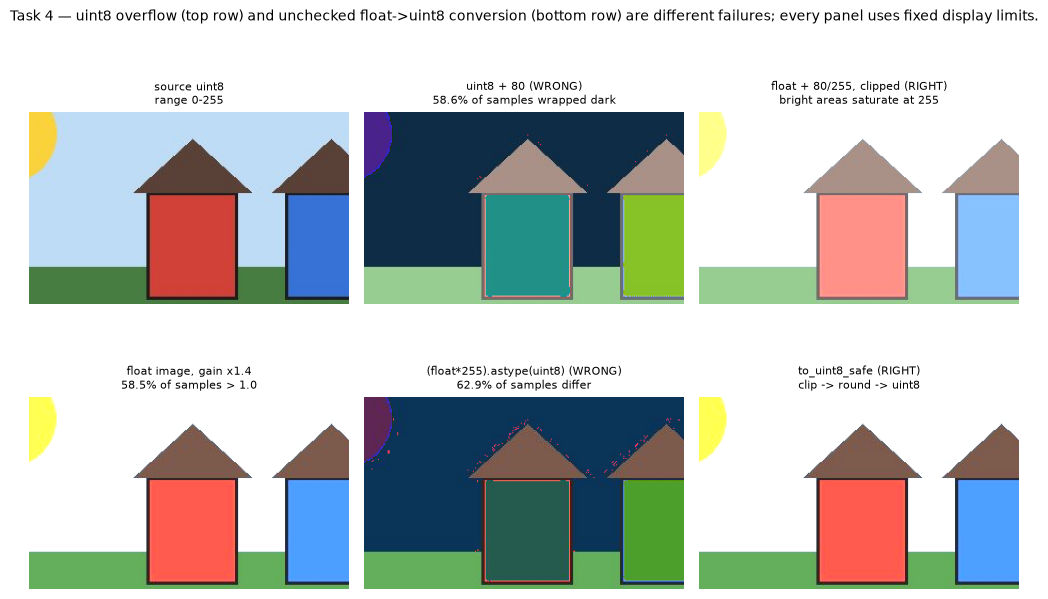

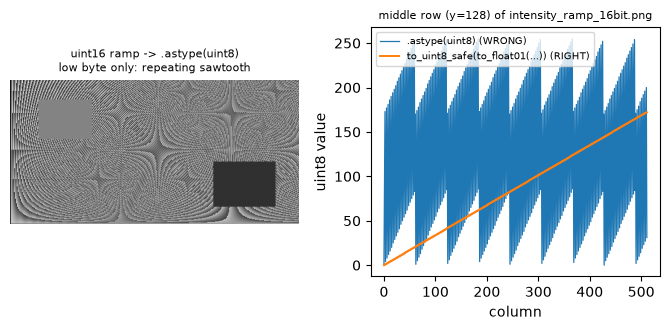

In [6]:
# STUDENT WORK — Task 4
# Two distinct failure mechanisms, held side by side on the same pixels:
#   (a) integer overflow   — uint8 arithmetic wraps modulo 256 before anything can clip it
#   (b) unsafe float->uint8 — out-of-range floats are truncated and wrapped by .astype(uint8)
paths = {p.name: p for p in a1_tools.discover_images()}
scene = iio.imread(paths["wide_scene.jpg"])              # uint8 RGB
ramp16 = iio.imread(paths["intensity_ramp_16bit.png"])   # uint16 grayscale
print(f"scene  {scene.shape} {scene.dtype} range {scene.min()}-{scene.max()}")
print(f"ramp16 {ramp16.shape} {ramp16.dtype} range {ramp16.min()}-{ramp16.max()}")

metrics_path = PATHS["tables"] / "experiment_metrics.csv"


def record_metrics(experiment, rows):
    """Append rows to the cumulative experiment_metrics.csv, replacing this experiment's
    previous rows so re-running a cell never duplicates or double-counts measurements."""
    fresh = pd.DataFrame(rows, columns=["experiment", "method", "condition", "metric", "value", "units"])
    if metrics_path.is_file():
        kept = pd.read_csv(metrics_path)
        kept = kept[kept["experiment"] != experiment]
        fresh = pd.concat([kept, fresh], ignore_index=True)
    fresh.to_csv(metrics_path, index=False)
    return fresh


# --- 1. the round trip that is safe by construction -------------------------------------
scene01 = sc.to_float01(scene)                 # uint8 -> float32 in [0, 1]
restored = sc.to_uint8_safe(scene01)           # float32 -> uint8, clip then round
round_trip_max_error = int(np.abs(restored.astype(np.int16) - scene.astype(np.int16)).max())
print(f"\nto_float01 dtype={scene01.dtype} range {scene01.min():.4f}-{scene01.max():.4f}; "
      f"round-trip max |error| = {round_trip_max_error}")

# --- 2. uint8 overflow: the same +80 in uint8 and in float ------------------------------
OFFSET = 80
uint8_add = scene + np.uint8(OFFSET)                     # wraps modulo 256
float_add = sc.to_uint8_safe(scene01 + np.float32(OFFSET / 255.0))   # clips at 1.0
wrapped = uint8_add < scene                              # brightening made a pixel darker
wrap_fraction = float(wrapped.mean())
overflow_max_gap = int(np.abs(float_add.astype(np.int16) - uint8_add.astype(np.int16)).max())
print(f"uint8 +{OFFSET}: {wrap_fraction:.2%} of samples wrapped to a DARKER value; "
      f"largest disagreement with the float path = {overflow_max_gap}")

# --- 3. unsafe float -> uint8 on a float image that leaves [0, 1] -----------------------
GAIN = 1.4
gained = (scene01 * np.float32(GAIN)).astype(np.float32)  # legitimate float image, range > 1
wrong = (gained * 255).astype(np.uint8)                   # no clip: truncates and wraps
right = sc.to_uint8_safe(gained)                          # clip -> round -> uint8
out_of_range = float((gained > 1.0).mean())
cast_max_gap = int(np.abs(right.astype(np.int16) - wrong.astype(np.int16)).max())
cast_disagree = float((right != wrong).mean())
print(f"float gain x{GAIN}: {out_of_range:.2%} of samples exceed 1.0; the unchecked cast "
      f"disagrees with to_uint8_safe on {cast_disagree:.2%} of samples (max gap {cast_max_gap})")

# --- 4. the 16-bit ramp: the scale lives in the dtype, not in the values ----------------
ramp01 = sc.to_float01(ramp16)                            # /65535
ramp_naive = ramp16.astype(np.uint8)                      # keeps the low byte only
ramp_scaled = sc.to_uint8_safe(ramp01)                    # correct 16 -> 8 bit rescale
ramp_row = ramp16.shape[0] // 2
ramp_monotonic = bool(np.all(np.diff(ramp_scaled[ramp_row].astype(np.int16)) >= 0))
naive_monotonic = bool(np.all(np.diff(ramp_naive[ramp_row].astype(np.int16)) >= 0))
print(f"uint16 ramp: rescaled row monotonic = {ramp_monotonic}; "
      f"naive .astype(uint8) row monotonic = {naive_monotonic} "
      f"(the low byte sawtooths {int((np.diff(ramp_naive[ramp_row].astype(np.int16)) < 0).sum())} times)")

# --- quantitative record ----------------------------------------------------------------
metrics = record_metrics("task4-dtype-range", [
    ("task4-dtype-range", "to_float01 -> to_uint8_safe", "wide_scene.jpg uint8",
     "max absolute round-trip error", round_trip_max_error, "levels"),
    ("task4-dtype-range", "uint8 addition", f"wide_scene.jpg +{OFFSET}",
     "fraction of samples wrapped darker", round(wrap_fraction, 6), "fraction"),
    ("task4-dtype-range", "float addition + to_uint8_safe", f"wide_scene.jpg +{OFFSET}",
     "max disagreement with uint8 addition", overflow_max_gap, "levels"),
    ("task4-dtype-range", "(float*255).astype(uint8)", f"wide_scene.jpg gain x{GAIN}",
     "fraction of samples disagreeing with to_uint8_safe", round(cast_disagree, 6), "fraction"),
    ("task4-dtype-range", "(float*255).astype(uint8)", f"wide_scene.jpg gain x{GAIN}",
     "max disagreement with to_uint8_safe", cast_max_gap, "levels"),
    ("task4-dtype-range", "uint16 .astype(uint8)", "intensity_ramp_16bit.png",
     "monotonic across the middle row", int(naive_monotonic), "boolean"),
    ("task4-dtype-range", "to_float01 -> to_uint8_safe", "intensity_ramp_16bit.png",
     "monotonic across the middle row", int(ramp_monotonic), "boolean"),
])
print("wrote", metrics_path)
display(metrics[metrics["experiment"] == "task4-dtype-range"])

# --- figure: both mechanisms, plus the 16-bit rescale -----------------------------------
CROP = (slice(60, 240), slice(120, 420))
fig, axes = a1_tools.axes_grid(2, 3, scale=3.4)
panels = [
    (scene[CROP], f"source uint8\nrange {scene.min()}-{scene.max()}"),
    (uint8_add[CROP], f"uint8 + {OFFSET} (WRONG)\n{wrap_fraction:.1%} of samples wrapped dark"),
    (float_add[CROP], f"float + {OFFSET}/255, clipped (RIGHT)\nbright areas saturate at 255"),
    (np.clip(gained[CROP], 0, 1), f"float image, gain x{GAIN}\n{out_of_range:.1%} of samples > 1.0"),
    (wrong[CROP], f"(float*255).astype(uint8) (WRONG)\n{cast_disagree:.1%} of samples differ"),
    (right[CROP], f"to_uint8_safe (RIGHT)\nclip -> round -> uint8"),
]
for ax, (data, title) in zip(axes.flat, panels):
    ax.imshow(data, vmin=0, vmax=1 if data.dtype.kind == "f" else 255)
    ax.set_title(title, fontsize=8)
    ax.axis("off")
fig.suptitle("Task 4 — uint8 overflow (top row) and unchecked float->uint8 conversion "
             "(bottom row) are different failures; every panel uses fixed display limits.",
             fontsize=10)
fig.tight_layout()
dtype_fig = PATHS["figures"] / "dtype_range_experiment.png"
fig.savefig(dtype_fig, dpi=150, bbox_inches="tight")
print("wrote", dtype_fig)
plt.show()

# --- the 16-bit ramp as a value profile, where the sawtooth is visible ------------------
fig2, axes2 = a1_tools.axes_grid(1, 2, scale=3.4)
axes2[0][0].imshow(ramp_naive, cmap="gray", vmin=0, vmax=255)
axes2[0][0].set_title("uint16 ramp -> .astype(uint8)\nlow byte only: repeating sawtooth", fontsize=8)
axes2[0][0].axis("off")
axes2[0][1].plot(ramp_naive[ramp_row], label=".astype(uint8) (WRONG)", linewidth=0.9)
axes2[0][1].plot(ramp_scaled[ramp_row], label="to_uint8_safe(to_float01(...)) (RIGHT)", linewidth=1.4)
axes2[0][1].set_title(f"middle row (y={ramp_row}) of intensity_ramp_16bit.png", fontsize=8)
axes2[0][1].set_xlabel("column"); axes2[0][1].set_ylabel("uint8 value"); axes2[0][1].legend(fontsize=7)
fig2.tight_layout()
plt.show()

**Task 4 analysis (3–5 sentences):** YOUR RESPONSE. Use observed values to explain overflow, clipping, normalization, and the corrected conversion.

# TODO: WRITE ANALYSIS



## 5. Required Experiments

### Experiment 1 — channel order and grayscale interpretation (8 points)

Implement both grayscale functions. Compare: correct RGB display; BGR interpreted as RGB; channel mean; luminance-weighted grayscale; and OpenCV grayscale with the correct input convention. Hold the source image and display limits fixed. Save `outputs/figures/color_representations.png`.


source (400, 640, 3) uint8; display scale fixed at [0, 1] float32
grayscale dtypes: mean float32, luminance float32, opencv uint8 -> float32

red-rectangle patch rows 65:245, cols 55:225 -> mean (R, G, B) = (209.7, 43.8, 43.8)
same patch read as BGR              -> mean (R, G, B) = (43.8, 43.8, 209.7)


,comparison,statistic,value,units
0,channel order: RGB vs BGR-as-RGB,mean |difference| (color),0.141279,float01
1,channel order: RGB vs BGR-as-RGB,max |difference| (color),0.823529,float01
2,grayscale rule: luminance - mean,mean signed difference,0.004102,float01
3,grayscale rule: luminance - mean,max |difference|,0.145810,float01
4,opencv gray (BGR in) vs my luminance,max |difference|,0.001902,float01
5,opencv gray: right vs wrong input convention,max |difference|,39.000000,levels
6,opencv gray: right vs wrong input convention,fraction of pixels differing,0.972301,fraction



wrote /home/sqmi/CS-5243-Computer-Vision/CS-5243-Computer-Vision/A1/outputs/figures/color_representations.png


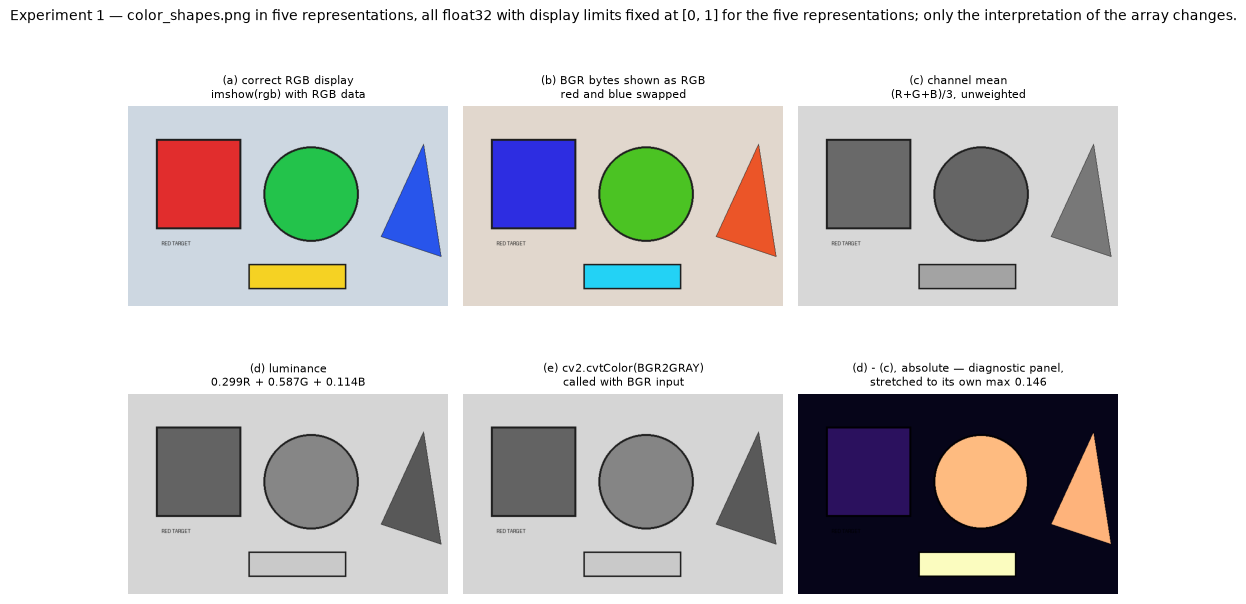

In [7]:
# STUDENT WORK — Experiment 1
# One fixed source image, one fixed display scale ([0, 1] float everywhere), five
# representations. Only the interpretation of the array changes between panels.
source_rgb = iio.imread(paths["color_shapes.png"])       # uint8 RGB as stored on disk
rgb01 = sc.to_float01(source_rgb)                        # float32 [0, 1] display scale

# (a) correct RGB display
correct = rgb01
# (b) the same bytes read as if they were BGR, then shown as RGB: a channel-order error
bgr_as_rgb = sc.to_float01(sc.bgr_to_rgb(source_rgb))
# (c) unweighted channel mean and (d) BT.601 luminance, both float32 in [0, 1]
mean_gray = sc.grayscale_mean(rgb01)
luma_gray = sc.grayscale_luminance(rgb01)
# (e) OpenCV grayscale, called with the input convention it documents (BGR in)
opencv_gray = cv2.cvtColor(sc.bgr_to_rgb(source_rgb), cv2.COLOR_BGR2GRAY)
opencv01 = sc.to_float01(opencv_gray)
# the same call made with the wrong convention, kept only as the control that shows the
# channel-order error is invisible in a grayscale image unless you measure it
opencv_gray_wrong = cv2.cvtColor(source_rgb, cv2.COLOR_BGR2GRAY)

print(f"source {source_rgb.shape} {source_rgb.dtype}; display scale fixed at [0, 1] float32")
print(f"grayscale dtypes: mean {mean_gray.dtype}, luminance {luma_gray.dtype}, "
      f"opencv {opencv_gray.dtype} -> {opencv01.dtype}")

# --- what separates a channel-order error from a grayscale-weighting choice ------------
import yaml   # already in the course environment; used only to read the provided ROI metadata
COLOR_TARGET = yaml.safe_load((A1 / "data" / "metadata" / "color_regions.yml").read_text())["color_target"]
x0, y0, x1, y1 = (int(v) for v in COLOR_TARGET["target_roi_xyxy"])
patch_rgb = source_rgb[y0:y1, x0:x1]                     # the red rectangle, per metadata
print(f"\nred-rectangle patch rows {y0}:{y1}, cols {x0}:{x1} -> mean (R, G, B) = "
      f"{tuple(round(float(v), 1) for v in patch_rgb.reshape(-1, 3).mean(axis=0))}")
print("same patch read as BGR              -> mean (R, G, B) = "
      f"{tuple(round(float(v), 1) for v in sc.bgr_to_rgb(patch_rgb).reshape(-1, 3).mean(axis=0))}")

luma_minus_mean = luma_gray - mean_gray
opencv_vs_luma = np.abs(opencv01 - luma_gray)
opencv_convention_gap = np.abs(opencv_gray.astype(np.int16) - opencv_gray_wrong.astype(np.int16))
comparisons = pd.DataFrame([
    {"comparison": "channel order: RGB vs BGR-as-RGB", "statistic": "mean |difference| (color)",
     "value": round(float(np.abs(correct - bgr_as_rgb).mean()), 6), "units": "float01"},
    {"comparison": "channel order: RGB vs BGR-as-RGB", "statistic": "max |difference| (color)",
     "value": round(float(np.abs(correct - bgr_as_rgb).max()), 6), "units": "float01"},
    {"comparison": "grayscale rule: luminance - mean", "statistic": "mean signed difference",
     "value": round(float(luma_minus_mean.mean()), 6), "units": "float01"},
    {"comparison": "grayscale rule: luminance - mean", "statistic": "max |difference|",
     "value": round(float(np.abs(luma_minus_mean).max()), 6), "units": "float01"},
    {"comparison": "opencv gray (BGR in) vs my luminance", "statistic": "max |difference|",
     "value": round(float(opencv_vs_luma.max()), 6), "units": "float01"},
    {"comparison": "opencv gray: right vs wrong input convention", "statistic": "max |difference|",
     "value": int(opencv_convention_gap.max()), "units": "levels"},
    {"comparison": "opencv gray: right vs wrong input convention", "statistic": "fraction of pixels differing",
     "value": round(float((opencv_convention_gap > 0).mean()), 6), "units": "fraction"},
])
display(comparisons)

# --- figure: five representations, identical source and identical display limits --------
fig, axes = a1_tools.axes_grid(2, 3, scale=3.4)
panels = [
    (correct, None, "(a) correct RGB display\nimshow(rgb) with RGB data"),
    (bgr_as_rgb, None, "(b) BGR bytes shown as RGB\nred and blue swapped"),
    (mean_gray, "gray", "(c) channel mean\n(R+G+B)/3, unweighted"),
    (luma_gray, "gray", "(d) luminance\n0.299R + 0.587G + 0.114B"),
    (opencv01, "gray", "(e) cv2.cvtColor(BGR2GRAY)\ncalled with BGR input"),
    (np.abs(luma_minus_mean), "magma", f"(d) - (c), absolute — diagnostic panel,\nstretched to its own max {np.abs(luma_minus_mean).max():.3f}"),
]
for position, (ax, (data, cmap, title)) in enumerate(zip(axes.flat, panels)):
    # the five representation panels share display limits [0, 1]; the last panel is a
    # difference image rather than a representation, so it is stretched to be readable
    upper = float(data.max()) if position == 5 else 1.0
    ax.imshow(data, cmap=cmap, vmin=0.0, vmax=upper)
    ax.set_title(title, fontsize=8)
    ax.axis("off")
fig.suptitle("Experiment 1 — color_shapes.png in five representations, all float32 with "
             "display limits fixed at [0, 1] for the five representations; only the "
             "interpretation of the array changes.", fontsize=10)
fig.tight_layout()
color_fig = PATHS["figures"] / "color_representations.png"
fig.savefig(color_fig, dpi=150, bbox_inches="tight")
print("\nwrote", color_fig)
plt.show()

**Experiment 1 analysis (4–6 sentences):** YOUR RESPONSE. State which evidence separates a channel-order error from a grayscale-weighting choice.

# TODO: WRITE ANALYSIS


### Experiment 2 — HSV rule stability (7 points)

Implement the inclusive OpenCV-HSV rule, including wrapped hue intervals. Use one rule and the exactly aligned normal, dim, and warm images. Report selected-pixel fraction (and one other useful metric) for every condition. Append the results to the cumulative `experiment_metrics.csv`. Save `outputs/figures/hsv_stability.png`. This is a controlled color-rule investigation, not a segmentation assignment.


rule: hue 170..179 and 0..10 (wrapped), saturation 100..255, value 60..255
target ROI (x0, y0, x1, y1) = [55, 65, 225, 245] — the red rectangle that is in the same place in all three images

normal selected  0.1102 of pixels · target coverage 92.15% · precision 100.00% · target-ROI median (H, S, V) = (0, 204, 225)
       clause pass rate inside the target ROI: hue 100.00%, saturation 92.15%, value 92.15%
dim    selected  0.0000 of pixels · target coverage  0.00% · precision  0.00% · target-ROI median (H, S, V) = (0, 85, 75)
       clause pass rate inside the target ROI: hue 100.00%, saturation 0.00%, value 92.15%
warm   selected  0.1381 of pixels · target coverage 100.00% · precision 86.56% · target-ROI median (H, S, V) = (3, 234, 240)
       clause pass rate inside the target ROI: hue 100.00%, saturation 100.00%, value 100.00%

wrote /home/sqmi/CS-5243-Computer-Vision/CS-5243-Computer-Vision/A1/outputs/tables/experiment_metrics.csv


,experiment,method,condition,metric,value,units
7,exp2-hsv-stability,hsv_rule 170-10 / S>=100 / V>=60,normal (color_shapes.png),selected-pixel fraction,0.110152,fraction
8,exp2-hsv-stability,hsv_rule 170-10 / S>=100 / V>=60,normal (color_shapes.png),target ROI coverage,0.921536,fraction
9,exp2-hsv-stability,hsv_rule 170-10 / S>=100 / V>=60,normal (color_shapes.png),precision inside target ROI,1.000000,fraction
10,exp2-hsv-stability,hsv_rule 170-10 / S>=100 / V>=60,normal (color_shapes.png),saturation clause pass rate in ROI,0.921536,fraction
11,exp2-hsv-stability,hsv_rule 170-10 / S>=100 / V>=60,normal (color_shapes.png),value clause pass rate in ROI,0.921536,fraction
12,exp2-hsv-stability,hsv_rule 170-10 / S>=100 / V>=60,dim (color_shapes_dim.png),selected-pixel fraction,0.000000,fraction
13,exp2-hsv-stability,hsv_rule 170-10 / S>=100 / V>=60,dim (color_shapes_dim.png),target ROI coverage,0.000000,fraction
14,exp2-hsv-stability,hsv_rule 170-10 / S>=100 / V>=60,dim (color_shapes_dim.png),precision inside target ROI,0.000000,fraction
15,exp2-hsv-stability,hsv_rule 170-10 / S>=100 / V>=60,dim (color_shapes_dim.png),saturation clause pass rate in ROI,0.000000,fraction
16,exp2-hsv-stability,hsv_rule 170-10 / S>=100 / V>=60,dim (color_shapes_dim.png),value clause pass rate in ROI,0.921536,fraction


wrote /home/sqmi/CS-5243-Computer-Vision/CS-5243-Computer-Vision/A1/outputs/figures/hsv_stability.png


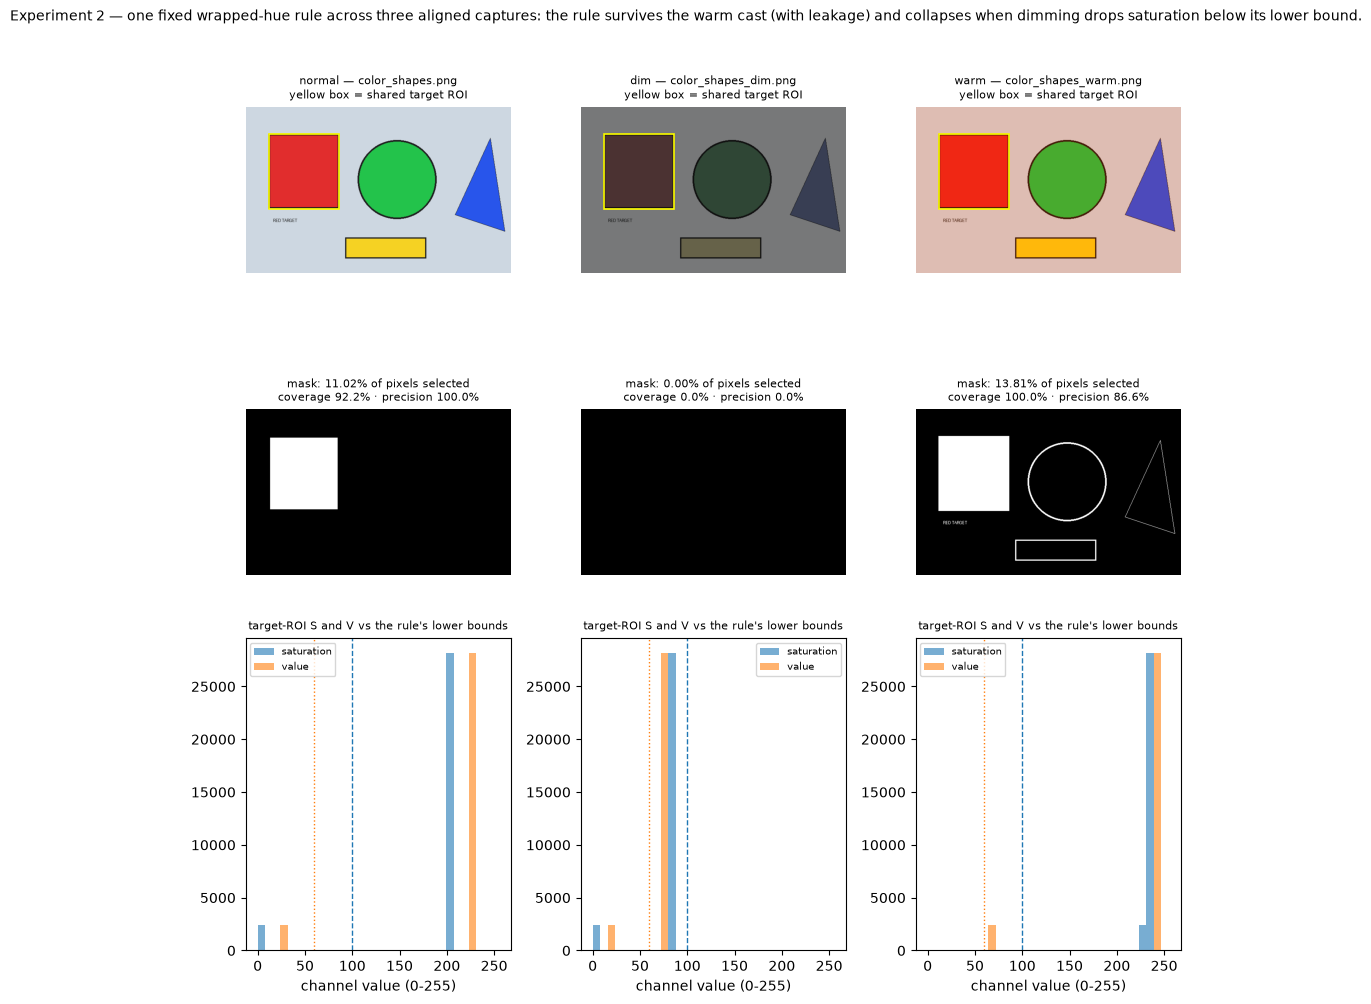

In [8]:
# STUDENT WORK — Experiment 2
# One rule, tuned on the normal image, applied unchanged to three exactly aligned images.
# The rule is the constant; the capture condition is the only variable.
RULE_LOWER, RULE_UPPER = (170, 100, 60), (10, 255, 255)   # wrapped hue: 170..179 and 0..10
CONDITIONS = {"normal": "color_shapes.png", "dim": "color_shapes_dim.png", "warm": "color_shapes_warm.png"}
print(f"rule: hue {RULE_LOWER[0]}..179 and 0..{RULE_UPPER[0]} (wrapped), "
      f"saturation {RULE_LOWER[1]}..{RULE_UPPER[1]}, value {RULE_LOWER[2]}..{RULE_UPPER[2]}")
print(f"target ROI (x0, y0, x1, y1) = {COLOR_TARGET['target_roi_xyxy']} — the red rectangle "
      "that is in the same place in all three images\n")

target_mask = np.zeros(iio.imread(paths[CONDITIONS["normal"]]).shape[:2], dtype=bool)
target_mask[y0:y1, x0:x1] = True

results, rows = {}, []
for condition, filename in CONDITIONS.items():
    rgb = iio.imread(paths[filename])
    hsv = cv2.cvtColor(sc.bgr_to_rgb(rgb), cv2.COLOR_BGR2HSV)   # cv2 expects BGR input
    mask = sc.hsv_rule(hsv, RULE_LOWER, RULE_UPPER)

    selected_fraction = float(mask.mean())
    hit = int((mask & target_mask).sum())
    coverage = hit / int(target_mask.sum())                      # how much of the target it keeps
    precision = hit / int(mask.sum()) if mask.any() else 0.0     # how much of what it keeps is target
    roi = hsv[y0:y1, x0:x1].reshape(-1, 3).astype(np.int32)
    # which clause of the rule each target pixel passes, so a failure can be attributed
    hue_ok = float(((roi[:, 0] >= RULE_LOWER[0]) | (roi[:, 0] <= RULE_UPPER[0])).mean())
    sat_ok = float(((roi[:, 1] >= RULE_LOWER[1]) & (roi[:, 1] <= RULE_UPPER[1])).mean())
    val_ok = float(((roi[:, 2] >= RULE_LOWER[2]) & (roi[:, 2] <= RULE_UPPER[2])).mean())
    results[condition] = {"rgb": rgb, "hsv": hsv, "mask": mask, "selected": selected_fraction,
                          "coverage": coverage, "precision": precision, "roi": roi}
    print(f"{condition:6s} selected {selected_fraction:7.4f} of pixels · target coverage "
          f"{coverage:6.2%} · precision {precision:6.2%} · target-ROI median (H, S, V) = "
          f"{tuple(int(v) for v in np.median(roi, axis=0))}")
    print(f"       clause pass rate inside the target ROI: hue {hue_ok:.2%}, "
          f"saturation {sat_ok:.2%}, value {val_ok:.2%}")

    label = f"{condition} ({filename})"
    rows += [
        ("exp2-hsv-stability", "hsv_rule 170-10 / S>=100 / V>=60", label,
         "selected-pixel fraction", round(selected_fraction, 6), "fraction"),
        ("exp2-hsv-stability", "hsv_rule 170-10 / S>=100 / V>=60", label,
         "target ROI coverage", round(coverage, 6), "fraction"),
        ("exp2-hsv-stability", "hsv_rule 170-10 / S>=100 / V>=60", label,
         "precision inside target ROI", round(precision, 6), "fraction"),
        ("exp2-hsv-stability", "hsv_rule 170-10 / S>=100 / V>=60", label,
         "saturation clause pass rate in ROI", round(sat_ok, 6), "fraction"),
        ("exp2-hsv-stability", "hsv_rule 170-10 / S>=100 / V>=60", label,
         "value clause pass rate in ROI", round(val_ok, 6), "fraction"),
    ]

metrics = record_metrics("exp2-hsv-stability", rows)     # appends to the cumulative table
print("\nwrote", metrics_path)
display(metrics[metrics["experiment"] == "exp2-hsv-stability"])

# --- figure: image, mask, and the distributions that explain each outcome ---------------
fig, axes = a1_tools.axes_grid(3, 3, scale=3.4)
for column, (condition, filename) in enumerate(CONDITIONS.items()):
    r = results[condition]
    top = axes[0][column]
    top.imshow(r["rgb"], vmin=0, vmax=255)
    top.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="yellow", lw=1.2))
    top.set_title(f"{condition} — {filename}\nyellow box = shared target ROI", fontsize=8)
    top.axis("off")

    mid = axes[1][column]
    mid.imshow(r["mask"], cmap="gray", vmin=0, vmax=1)
    mid.set_title(f"mask: {r['selected']:.2%} of pixels selected\n"
                  f"coverage {r['coverage']:.1%} · precision {r['precision']:.1%}", fontsize=8)
    mid.axis("off")

    bottom = axes[2][column]
    bottom.hist(r["roi"][:, 1], bins=32, range=(0, 255), alpha=0.6, label="saturation")
    bottom.hist(r["roi"][:, 2], bins=32, range=(0, 255), alpha=0.6, label="value")
    bottom.axvline(RULE_LOWER[1], color="tab:blue", ls="--", lw=1)
    bottom.axvline(RULE_LOWER[2], color="tab:orange", ls=":", lw=1)
    bottom.set_title("target-ROI S and V vs the rule's lower bounds", fontsize=8)
    bottom.set_xlabel("channel value (0-255)")
    bottom.legend(fontsize=7)
fig.suptitle("Experiment 2 — one fixed wrapped-hue rule across three aligned captures: "
             "the rule survives the warm cast (with leakage) and collapses when dimming "
             "drops saturation below its lower bound.", fontsize=10)
fig.tight_layout()
hsv_fig = PATHS["figures"] / "hsv_stability.png"
fig.savefig(hsv_fig, dpi=150, bbox_inches="tight")
print("wrote", hsv_fig)
plt.show()

**Experiment 2 analysis (3–5 sentences):** YOUR RESPONSE. Explain the strongest and weakest condition using HSV evidence, without claiming general segmentation performance.

# TODO: WRITE ANALYSIS


### Experiment 3 — video as a sampled visual array (4 points)

Probe `moving_shapes.mp4` and record the required input, output, and read-back structure in `outputs/tables/video_metadata.json`. Extract frames near 0.0, 1.0, 2.0, and 3.0 seconds and save `outputs/figures/video_contact_sheet.png`. Implement `transform_frame` to flip an RGB frame horizontally and multiply its red channel by `0.65`, returning `HxWx3 uint8`. Apply it to all frames, write `outputs/videos/a1_transformed.mp4` using `a1_tools.write_mp4`, then verify read-back with `a1_tools.verify_video_round_trip`. The bundled imageio-ffmpeg path is required; OpenCV `VideoWriter` is not graded or required.


input : {'path': 'moving_shapes.mp4', 'width': 320, 'height': 240, 'fps': 12.0, 'frame_count': 48, 'duration_seconds': 4.0, 'codec': 'h264'}
wrote /home/sqmi/CS-5243-Computer-Vision/CS-5243-Computer-Vision/A1/outputs/figures/video_contact_sheet.png


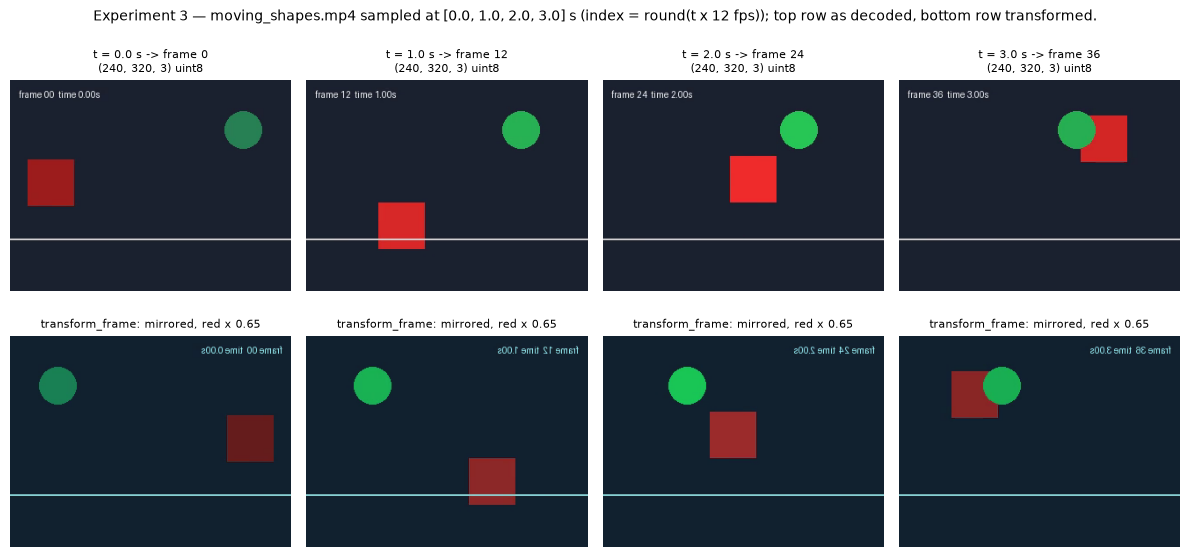


transformed 48 frames; first frame (240, 320, 3) uint8
wrote /home/sqmi/CS-5243-Computer-Vision/CS-5243-Computer-Vision/A1/outputs/videos/a1_transformed.mp4 (26.5 KiB)
output: {'path': 'a1_transformed.mp4', 'width': 320, 'height': 240, 'fps': 12.0, 'frame_count': 48, 'duration_seconds': 4.0, 'codec': 'h264'}
read-back checks: {'resolution': True, 'fps': True, 'frame_count': True} -> valid: True
wrote /home/sqmi/CS-5243-Computer-Vision/CS-5243-Computer-Vision/A1/outputs/tables/video_metadata.json

frame 0 after H.264 re-encode: mean |difference| 0.86, max 46 levels — structure round-trips, exact sample values do not


In [9]:
# STUDENT WORK — Experiment 3
video_in = A1 / "data" / "video" / "moving_shapes.mp4"
probe_in = a1_tools.probe_video(video_in)
print("input :", probe_in)

# --- sample frames at fixed times: index = round(time * fps), not time * frame_count ----
SAMPLE_TIMES = [0.0, 1.0, 2.0, 3.0]
samples = a1_tools.sample_video_frames(video_in, SAMPLE_TIMES)
fps = float(probe_in["fps"])
fig, axes = a1_tools.axes_grid(2, len(SAMPLE_TIMES), scale=3.0)
for column, (t, frame) in enumerate(zip(SAMPLE_TIMES, samples)):
    index = round(t * fps)
    axes[0][column].imshow(frame, vmin=0, vmax=255)
    axes[0][column].set_title(f"t = {t:.1f} s -> frame {index}\n{frame.shape} {frame.dtype}", fontsize=8)
    axes[0][column].axis("off")
    axes[1][column].imshow(sc.transform_frame(frame), vmin=0, vmax=255)
    axes[1][column].set_title("transform_frame: mirrored, red x 0.65", fontsize=8)
    axes[1][column].axis("off")
fig.suptitle(f"Experiment 3 — moving_shapes.mp4 sampled at {SAMPLE_TIMES} s "
             f"(index = round(t x {fps:g} fps)); top row as decoded, bottom row transformed.",
             fontsize=10)
fig.tight_layout()
sheet_path = PATHS["figures"] / "video_contact_sheet.png"
fig.savefig(sheet_path, dpi=150, bbox_inches="tight")
print("wrote", sheet_path)
plt.show()

# --- transform every frame and write the result through the bundled ffmpeg path ---------
transformed = [sc.transform_frame(frame) for frame in a1_tools.iter_video_frames(video_in)]
print(f"\ntransformed {len(transformed)} frames; first frame {transformed[0].shape} {transformed[0].dtype}")
video_out = PATHS["videos"] / "a1_transformed.mp4"
a1_tools.write_mp4(video_out, transformed, fps=fps)
print("wrote", video_out, f"({a1_tools.format_bytes(video_out.stat().st_size)})")

read_back = a1_tools.verify_video_round_trip(
    video_out, expected_width=int(probe_in["width"]), expected_height=int(probe_in["height"]),
    expected_fps=fps, expected_frames=len(transformed))
probe_out = a1_tools.probe_video(video_out)
print("output:", probe_out)
print("read-back checks:", read_back["checks"], "-> valid:", read_back["valid"])

# --- record input, output, and read-back structure --------------------------------------
video_metadata = {
    "input": {**probe_in, "path": video_in.name},
    "output": {**probe_out, "path": video_out.name},
    "read_back": {"valid": bool(read_back["valid"]),
                  "checks": {name: bool(ok) for name, ok in read_back["checks"].items()},
                  "metadata": read_back["metadata"]},
    "transform": {"function": "student_code.transform_frame",
                  "operations": ["horizontal flip", "red channel x 0.65"],
                  "frames_written": len(transformed)},
}
video_json = PATHS["tables"] / "video_metadata.json"
video_json.write_text(json.dumps(video_metadata, indent=2, default=str), encoding="utf-8")
print("wrote", video_json)

# lossy re-encoding means the round trip is structural, not exact: quantify the difference
decoded_first = next(iter(a1_tools.iter_video_frames(video_out)))
delta = np.abs(decoded_first.astype(np.int16) - transformed[0].astype(np.int16))
print(f"\nframe 0 after H.264 re-encode: mean |difference| {delta.mean():.2f}, "
      f"max {int(delta.max())} levels — structure round-trips, exact sample values do not")

**Experiment 3 analysis (3–4 sentences):** YOUR RESPONSE. Cite input/output metadata and state what read-back proves—and what it does not prove.

# TODO: WRITE ANALYSIS



## 6. Results and Analysis

The immediate analysis prompts following Tasks 1–4 and Experiments 1–3 are worth **5 points collectively**. Use this synthesis to connect your findings rather than restating earlier observations. The final synthesis is worth **3 points**: in at most 180 words, address only (1) the most important representation lesson, (2) the strongest experimental finding, and (3) one important limitation observed in the completed experiments. Tie each claim to a saved artifact or measured value.


**Final synthesis:** YOUR RESPONSE.

# TODO: WRITE ANALYSIS


## 7. Failure Analysis

### Task 5 — evidence, mechanism, correction (7 points)

Document two failures: one image-representation failure and one video/encoding-related failure. One acceptable controlled video case is calculating a frame index using `time × frame_count` instead of `time × FPS`. Show the incorrect result, explain the units error, correct it, and verify the corrected frame selection. You may instead analyze another reproducible video or encoding-related failure. Save `outputs/figures/failure_image.png` and `outputs/figures/failure_video.png`.


image shape (400, 640, 3) = (height, width, channels); the yellow bar is at (x, y, w, h) = (243, 318, 190, 45)
crop_image(top=243, left=318) — x fed into the row axis -> mean (R, G, B) = (156.1, 199.9, 179.7)
crop_image(top=318, left=243) — rows then columns       -> mean (R, G, B) = (245.0, 210.0, 35.0)
blue triangle with x and y swapped: ValueError — rectangle (top=506, left=79, h=221, w=119) is out of bounds for image (400, 640)
Mechanism: NumPy indexes (row, column) = (y, x), but regions are usually written (x, y). Feeding x into the row axis returns a valid, in-bounds, WRONG rectangle whenever the swapped origin still fits inside the image — no exception, just the wrong pixels; it only raises when the swapped origin falls outside.

wrote /home/sqmi/CS-5243-Computer-Vision/CS-5243-Computer-Vision/A1/outputs/figures/failure_image.png


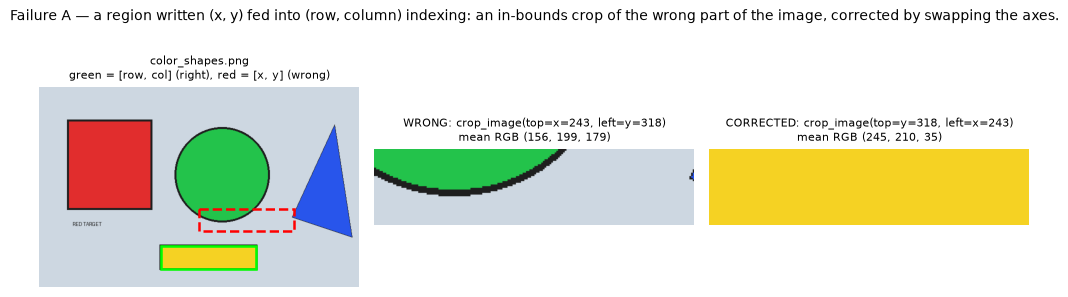


moving_shapes.mp4: 48 frames at 12 fps = 4.0 s of video


,time_s,wrong_index (t * frame_count),clamped_to,right_index (t * fps),in_range,identical_frame
0,0.0,0,0,0,True,True
1,1.0,48,47,12,False,False
2,2.0,96,47,24,False,False
3,3.0,144,47,36,False,False


Mechanism: a units error. t * frame_count has units of frames x seconds / video, not frames. It agrees with the correct index only at t = 0; for every later timestamp it overshoots by a factor of frame_count / fps = 4 (the duration), runs past the end of the video, and — because the read is clamped rather than checked — silently returns the LAST frame for every timestamp.

wrote /home/sqmi/CS-5243-Computer-Vision/CS-5243-Computer-Vision/A1/outputs/figures/failure_video.png


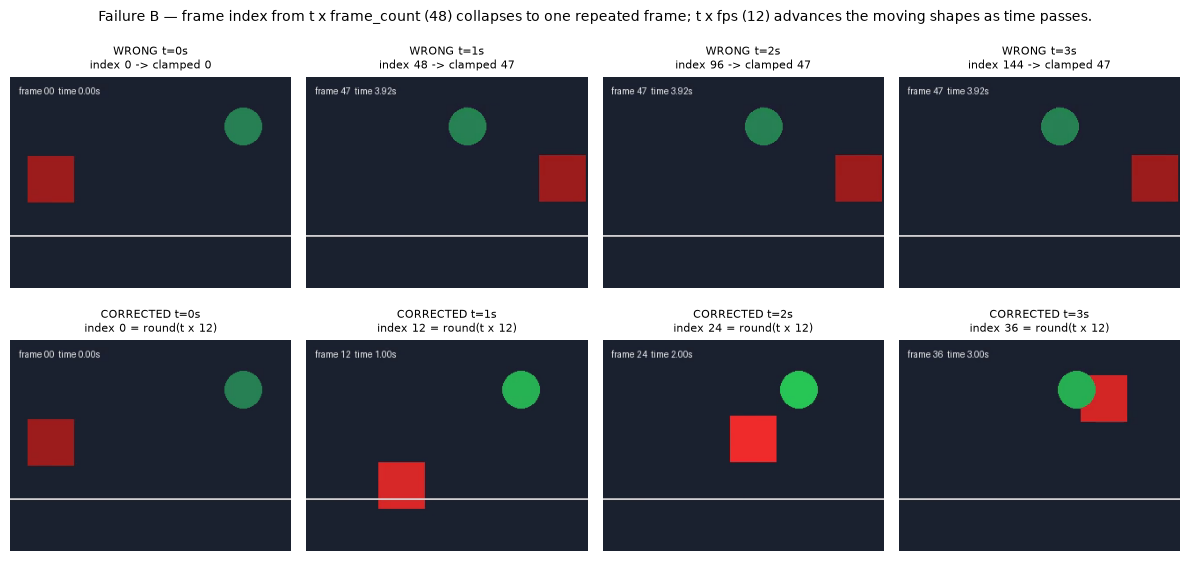

corrected frames are pairwise distinct: True; they match a1_tools.sample_video_frames: True


In [10]:
# STUDENT WORK — Failure evidence
# Failure A (image representation): indexing an image as [x, y] instead of [row, column].
# Failure B (video/encoding): converting a timestamp to a frame index with the frame COUNT
# instead of the frame RATE. Both are shown wrong first, then diagnosed and corrected.

# ======================= Failure A — axis order in a crop ==============================
scene = iio.imread(paths["color_shapes.png"])
# a region written the way image regions usually are written down: (x, y, width, height)
BAR_XYWH = (243, 318, 190, 45)      # the yellow bar, measured from the image
TRIANGLE_XYWH = (506, 79, 119, 221)  # the blue triangle, near the right edge
bx, by, bw, bh = BAR_XYWH
wrong_crop = sc.crop_image(scene, top=bx, left=by, height=bh, width=bw)   # x and y swapped
right_crop = sc.crop_image(scene, top=by, left=bx, height=bh, width=bw)
wrong_mean = wrong_crop.reshape(-1, 3).mean(axis=0)
right_mean = right_crop.reshape(-1, 3).mean(axis=0)
print(f"image shape {scene.shape} = (height, width, channels); the yellow bar is at "
      f"(x, y, w, h) = {BAR_XYWH}")
print(f"crop_image(top={bx}, left={by}) — x fed into the row axis -> mean (R, G, B) = "
      f"{tuple(round(float(v), 1) for v in wrong_mean)}")
print(f"crop_image(top={by}, left={bx}) — rows then columns       -> mean (R, G, B) = "
      f"{tuple(round(float(v), 1) for v in right_mean)}")

# the same mistake on a region near the right edge does raise, which is why the bar case is
# the dangerous one: whether the bug is loud or silent depends only on where the region sits
tx, ty, tw, th = TRIANGLE_XYWH
try:
    sc.crop_image(scene, top=tx, left=ty, height=th, width=tw)
    print("blue triangle with x and y swapped: no error (unexpected)")
except ValueError as error:
    print(f"blue triangle with x and y swapped: ValueError — {error}")
print("Mechanism: NumPy indexes (row, column) = (y, x), but regions are usually written "
      "(x, y). Feeding x into the row axis returns a valid, in-bounds, WRONG rectangle "
      "whenever the swapped origin still fits inside the image — no exception, just the "
      "wrong pixels; it only raises when the swapped origin falls outside.\n")

fig, axes = a1_tools.axes_grid(1, 3, scale=3.4)
axes[0][0].imshow(scene, vmin=0, vmax=255)
axes[0][0].add_patch(plt.Rectangle((bx, by), bw, bh, fill=False, edgecolor="lime", lw=1.8))
axes[0][0].add_patch(plt.Rectangle((by, bx), bw, bh, fill=False, edgecolor="red", lw=1.8, ls="--"))
axes[0][0].set_title("color_shapes.png\ngreen = [row, col] (right), red = [x, y] (wrong)", fontsize=8)
axes[0][0].axis("off")
axes[0][1].imshow(wrong_crop, vmin=0, vmax=255)
axes[0][1].set_title(f"WRONG: crop_image(top=x={bx}, left=y={by})\nmean RGB "
                     f"{tuple(int(v) for v in wrong_mean)}", fontsize=8)
axes[0][1].axis("off")
axes[0][2].imshow(right_crop, vmin=0, vmax=255)
axes[0][2].set_title(f"CORRECTED: crop_image(top=y={by}, left=x={bx})\nmean RGB "
                     f"{tuple(int(v) for v in right_mean)}", fontsize=8)
axes[0][2].axis("off")
fig.suptitle("Failure A — a region written (x, y) fed into (row, column) indexing: an "
             "in-bounds crop of the wrong part of the image, corrected by swapping the axes.",
             fontsize=10)
fig.tight_layout()
failure_image = PATHS["figures"] / "failure_image.png"
fig.savefig(failure_image, dpi=150, bbox_inches="tight")
print("wrote", failure_image)
plt.show()

# ==================== Failure B — timestamp to frame index ==============================
frames = list(a1_tools.iter_video_frames(video_in))
frame_count, fps = len(frames), float(probe_in["fps"])
TIMES = [0.0, 1.0, 2.0, 3.0]
print(f"\nmoving_shapes.mp4: {frame_count} frames at {fps:g} fps = "
      f"{frame_count / fps:.1f} s of video")

rows = []
for t in TIMES:
    wrong_index = int(round(t * frame_count))          # frames per VIDEO, not frames per second
    right_index = int(round(t * fps))                  # frames per SECOND -> a frame index
    clamped = min(wrong_index, frame_count - 1)        # what an unchecked read actually returns
    rows.append({"time_s": t, "wrong_index (t * frame_count)": wrong_index,
                 "clamped_to": clamped, "right_index (t * fps)": right_index,
                 "in_range": wrong_index < frame_count,
                 "identical_frame": bool(np.array_equal(frames[clamped], frames[right_index]))})
index_table = pd.DataFrame(rows)
display(index_table)
print("Mechanism: a units error. t * frame_count has units of frames x seconds / video, not "
      "frames. It agrees with the correct index only at t = 0; for every later timestamp it "
      f"overshoots by a factor of frame_count / fps = {frame_count / fps:.0f} (the duration), "
      "runs past the end of the video, and — because the read is clamped rather than checked — "
      "silently returns the LAST frame for every timestamp.\n")

fig, axes = a1_tools.axes_grid(2, len(TIMES), scale=3.0)
for column, row in enumerate(rows):
    axes[0][column].imshow(frames[row["clamped_to"]], vmin=0, vmax=255)
    axes[0][column].set_title(f"WRONG t={row['time_s']:.0f}s\nindex {row['wrong_index (t * frame_count)']}"
                              f" -> clamped {row['clamped_to']}", fontsize=8)
    axes[0][column].axis("off")
    axes[1][column].imshow(frames[row["right_index (t * fps)"]], vmin=0, vmax=255)
    axes[1][column].set_title(f"CORRECTED t={row['time_s']:.0f}s\nindex {row['right_index (t * fps)']}"
                              f" = round(t x {fps:g})", fontsize=8)
    axes[1][column].axis("off")
fig.suptitle(f"Failure B — frame index from t x frame_count ({frame_count}) collapses to one "
             f"repeated frame; t x fps ({fps:g}) advances the moving shapes as time passes.",
             fontsize=10)
fig.tight_layout()
failure_video = PATHS["figures"] / "failure_video.png"
fig.savefig(failure_video, dpi=150, bbox_inches="tight")
print("wrote", failure_video)
plt.show()

# verification of the correction: the corrected indices select distinct, advancing frames
corrected = [frames[int(round(t * fps))] for t in TIMES]
distinct = all(not np.array_equal(a, b) for a, b in zip(corrected, corrected[1:]))
matches_helper = all(np.array_equal(a, b) for a, b in
                     zip(corrected, a1_tools.sample_video_frames(video_in, TIMES)))
print(f"corrected frames are pairwise distinct: {distinct}; "
      f"they match a1_tools.sample_video_frames: {matches_helper}")

**Image failure analysis:** YOUR RESPONSE.

# TODO: WRITE ANALYSIS


**Video failure analysis:** YOUR RESPONSE.

# TODO: WRITE ANALYSIS



## 8. Extension

### Task 6 — Extension (4 points)

Choose one: color-based highlighting; short video summary; another color representation; false-color visualization; compression/resizing comparison; or visual storytelling with existing transformations. Require only **one clear question, one controlled comparison, one principal saved output, and one concise evidence-based conclusion**. Use no additional packages or major algorithms. Retain exactly one file under `outputs/extension/` (PNG, JPG, MP4, CSV, JSON, or TXT); delete any temporary extension files before submission.


,encoding,quality,kib,selected_fraction,roi_coverage,precision,mask_agreement_vs_png,max_rgb_error
0,PNG (lossless),NaN,4.2,0.11015,0.92154,1.00000,1.00000,0
1,JPEG,95.0,24.1,0.11272,0.94301,1.00000,0.99743,104
2,JPEG,80.0,15.8,0.11274,0.94317,1.00000,0.99741,124
3,JPEG,60.0,12.5,0.11225,0.93899,0.99990,0.99790,132
4,JPEG,40.0,11.0,0.11258,0.94180,0.99997,0.99757,160
5,JPEG,20.0,8.8,0.11405,0.95415,0.99997,0.99610,198
6,JPEG,10.0,7.2,0.11355,0.94964,0.99969,0.99659,225


PNG reference: 4.2 KiB, coverage 0.9215, precision 1.0000
most compressed JPEG tested (q10): 7.2 KiB, coverage 0.9496, precision 0.9997, mask agreement 0.9966, max per-sample RGB error 225 levels
weakest JPEG condition by coverage: 0.9390 at q60; the spread across all qualities is only 0.0152
file size, worth noting: on this flat synthetic image the lossless PNG is the SMALLEST file at 4.2 KiB — every JPEG tested is larger (q95 24.1 KiB, q10 7.2 KiB), because JPEG spends bits coding the ringing it introduces at hard color edges

wrote /home/sqmi/CS-5243-Computer-Vision/CS-5243-Computer-Vision/A1/outputs/extension/jpeg_quality_vs_hsv_rule.png


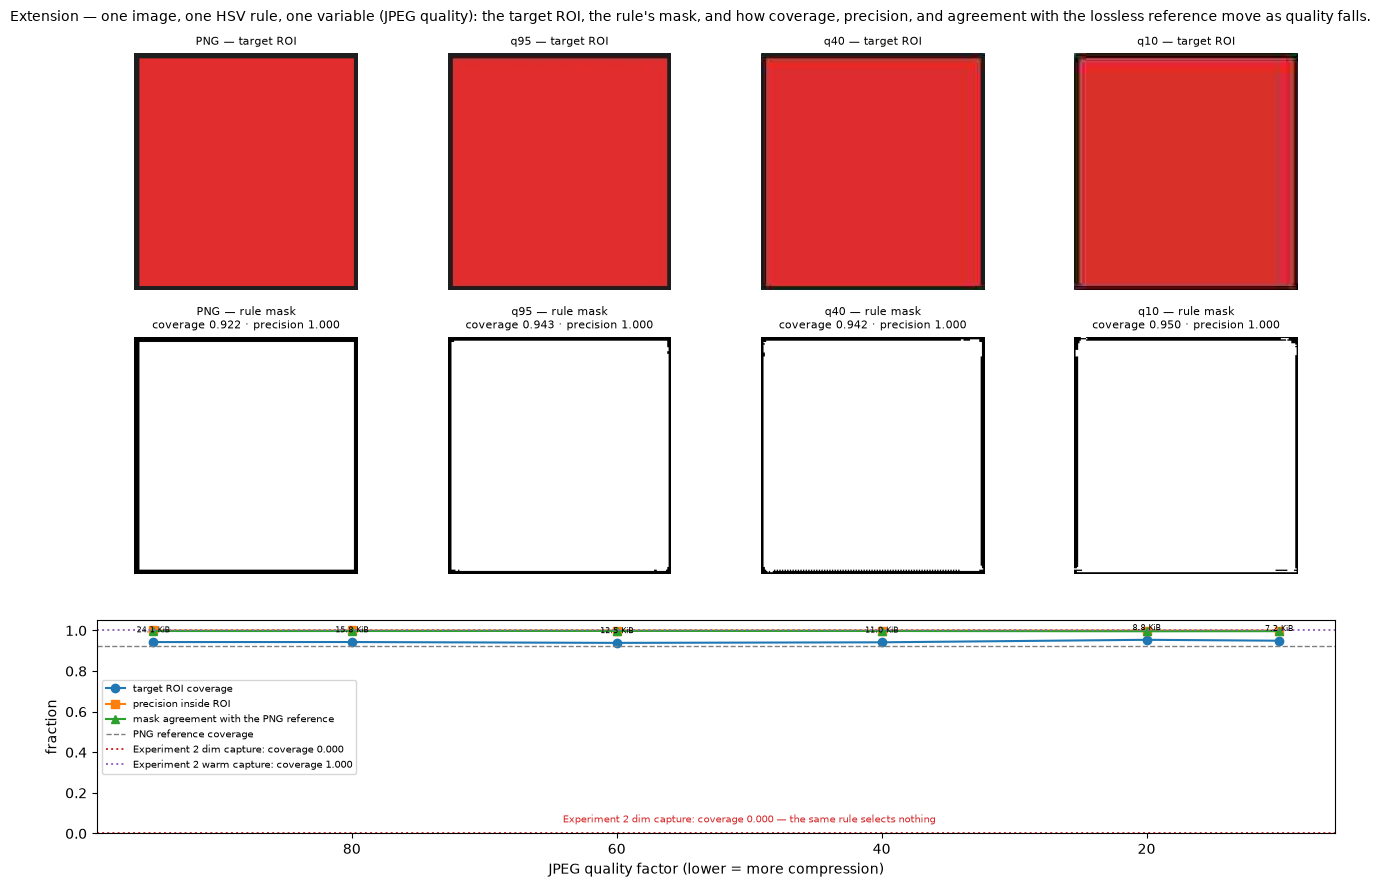

outputs/extension/ contains: ['jpeg_quality_vs_hsv_rule.png']


In [11]:
# STUDENT WORK — Extension
# QUESTION: Experiment 2 showed the HSV rule is sensitive to the capture condition. Storage
# is also a capture condition — so how much JPEG compression can color_shapes.png survive
# before the SAME rule stops selecting the SAME target?
# CONTROLLED COMPARISON: one image, one rule (RULE_LOWER/RULE_UPPER from Experiment 2), one
# variable — the JPEG quality factor. PNG (lossless) is the reference condition.
reference = iio.imread(paths["color_shapes.png"])
QUALITIES = [95, 80, 60, 40, 20, 10]


def rule_scores(rgb_image):
    """Selected fraction, target coverage, and precision for the Experiment 2 rule."""
    hsv = cv2.cvtColor(sc.bgr_to_rgb(rgb_image), cv2.COLOR_BGR2HSV)
    mask = sc.hsv_rule(hsv, RULE_LOWER, RULE_UPPER)
    hit = int((mask & target_mask).sum())
    return {"selected": float(mask.mean()),
            "coverage": hit / int(target_mask.sum()),
            "precision": hit / int(mask.sum()) if mask.any() else 0.0,
            "mask": mask}


png_bytes = paths["color_shapes.png"].stat().st_size
rows, decoded_images = [], {}
base = rule_scores(reference)
rows.append({"encoding": "PNG (lossless)", "quality": None, "kib": round(png_bytes / 1024, 1),
             "selected_fraction": round(base["selected"], 5), "roi_coverage": round(base["coverage"], 5),
             "precision": round(base["precision"], 5), "mask_agreement_vs_png": 1.0,
             "max_rgb_error": 0})
decoded_images["PNG"] = reference

for quality in QUALITIES:
    ok, buffer = cv2.imencode(".jpg", sc.bgr_to_rgb(reference),          # cv2 encodes BGR
                              [int(cv2.IMWRITE_JPEG_QUALITY), quality])
    assert ok, f"JPEG encode failed at quality {quality}"
    decoded = sc.bgr_to_rgb(cv2.imdecode(buffer, cv2.IMREAD_COLOR))      # back to RGB
    scores = rule_scores(decoded)
    decoded_images[f"q{quality}"] = decoded
    rows.append({
        "encoding": "JPEG", "quality": quality, "kib": round(buffer.nbytes / 1024, 1),
        "selected_fraction": round(scores["selected"], 5),
        "roi_coverage": round(scores["coverage"], 5),
        "precision": round(scores["precision"], 5),
        "mask_agreement_vs_png": round(float((scores["mask"] == base["mask"]).mean()), 5),
        "max_rgb_error": int(np.abs(decoded.astype(np.int16) - reference.astype(np.int16)).max()),
    })

comparison = pd.DataFrame(rows)
display(comparison)

jpeg_rows = comparison[comparison["encoding"] == "JPEG"]
most_compressed = jpeg_rows.iloc[-1]
least_coverage = jpeg_rows.loc[jpeg_rows["roi_coverage"].idxmin()]
print(f"PNG reference: {png_bytes / 1024:.1f} KiB, coverage {base['coverage']:.4f}, "
      f"precision {base['precision']:.4f}")
print(f"most compressed JPEG tested (q{int(most_compressed['quality'])}): {most_compressed['kib']} KiB, "
      f"coverage {most_compressed['roi_coverage']:.4f}, precision {most_compressed['precision']:.4f}, "
      f"mask agreement {most_compressed['mask_agreement_vs_png']:.4f}, max per-sample RGB error "
      f"{int(most_compressed['max_rgb_error'])} levels")
print(f"weakest JPEG condition by coverage: {least_coverage['roi_coverage']:.4f} at "
      f"q{int(least_coverage['quality'])}; the spread across all qualities is only "
      f"{jpeg_rows['roi_coverage'].max() - jpeg_rows['roi_coverage'].min():.4f}")
print(f"file size, worth noting: on this flat synthetic image the lossless PNG is the SMALLEST "
      f"file at {png_bytes / 1024:.1f} KiB — every JPEG tested is larger "
      f"(q95 {jpeg_rows.iloc[0]['kib']} KiB, q10 {most_compressed['kib']} KiB), because JPEG "
      "spends bits coding the ringing it introduces at hard color edges")

# --- one principal saved output ----------------------------------------------------------
PANELS = ["PNG", "q95", "q40", "q10"]
fig = plt.figure(figsize=(13.2, 9.0))
grid = fig.add_gridspec(3, len(PANELS), height_ratios=[1.0, 1.0, 0.9])
for position, key in enumerate(PANELS):
    scores = rule_scores(decoded_images[key])
    top = fig.add_subplot(grid[0, position])
    top.imshow(decoded_images[key][y0:y1, x0:x1], vmin=0, vmax=255)
    top.set_title(f"{key} — target ROI", fontsize=8)
    top.axis("off")
    mid = fig.add_subplot(grid[1, position])
    mid.imshow(scores["mask"][y0:y1, x0:x1], cmap="gray", vmin=0, vmax=1)
    mid.set_title(f"{key} — rule mask\ncoverage {scores['coverage']:.3f} · "
                  f"precision {scores['precision']:.3f}", fontsize=8)
    mid.axis("off")

curve = fig.add_subplot(grid[2, :])
curve.plot(jpeg_rows["quality"], jpeg_rows["roi_coverage"], "o-", label="target ROI coverage")
curve.plot(jpeg_rows["quality"], jpeg_rows["precision"], "s-", label="precision inside ROI")
curve.plot(jpeg_rows["quality"], jpeg_rows["mask_agreement_vs_png"], "^-",
           label="mask agreement with the PNG reference")
curve.axhline(base["coverage"], color="grey", ls="--", lw=1, label="PNG reference coverage")
# the scale of the effect only means something next to Experiment 2's lighting conditions
curve.axhline(results["dim"]["coverage"], color="tab:red", ls=":", lw=1.4,
              label=f"Experiment 2 dim capture: coverage {results['dim']['coverage']:.3f}")
curve.axhline(results["warm"]["coverage"], color="tab:purple", ls=":", lw=1.4,
              label=f"Experiment 2 warm capture: coverage {results['warm']['coverage']:.3f}")
curve.set_xlabel("JPEG quality factor (lower = more compression)")
curve.set_ylabel("fraction")
curve.set_ylim(0.0, 1.05)
curve.invert_xaxis()
curve.legend(fontsize=7, loc="center left")
curve.annotate("Experiment 2 dim capture: coverage 0.000 — the same rule selects nothing",
               xy=(float(jpeg_rows["quality"].median()), 0.0), xytext=(0, 8),
               textcoords="offset points", fontsize=7, color="tab:red", ha="center")
for _, row in jpeg_rows.iterrows():
    curve.annotate(f"{row['kib']} KiB", (row["quality"], row["roi_coverage"]),
                   textcoords="offset points", xytext=(0, 7), fontsize=6, ha="center")
fig.suptitle("Extension — one image, one HSV rule, one variable (JPEG quality): the target "
             "ROI, the rule's mask, and how coverage, precision, and agreement with the "
             "lossless reference move as quality falls.", fontsize=10)
fig.tight_layout()
extension_fig = PATHS["extension"] / "jpeg_quality_vs_hsv_rule.png"
fig.savefig(extension_fig, dpi=150, bbox_inches="tight")
print("\nwrote", extension_fig)
plt.show()
print("outputs/extension/ contains:", sorted(p.name for p in PATHS["extension"].glob("*") if p.is_file()))

**Question and conclusion (80–130 words total):** YOUR RESPONSE.

# TODO: WRITE ANALYSIS



## 9. Reflection and Reproducibility

In 100–150 words: state one practice you will carry into later assignments; one result another person should be able to reproduce; and any platform-dependent behavior. Update the assistance disclosure in Section 0. Do not restate all experiment findings.


**Reflection:** YOUR RESPONSE.

# TODO: WRITE ANALYSIS



## 10. Submission Validation

Restart the kernel and run all cells. Export current HTML as `A1.html`. Then run full validation and packaging using the absolute repository path if your terminal is elsewhere:

```bash
python /path/to/common-setup/scripts/validate_submission.py --assignment A1
python /path/to/common-setup/scripts/package_submission.py --assignment A1
```

Submit the generated ASCII-safe `LastName_FirstName_A1.zip`. It must contain one top-level folder with the executed notebook, current HTML, source, selected outputs, and validation report. Do not submit a PDF, datasets, caches, environments, checkpoints, or ZIPs inside the ZIP.


### Canvas submission checklist

- [ ] The ZIP contains exactly one top-level folder named `LastName_FirstName_A1`.
- [ ] Section 0 identity fields (first name, last name, ABC123) are complete.
- [ ] `A1.ipynb` was restarted, run top to bottom, and saved without errors, and `A1.html` was exported after that final run.
- [ ] `src/` contains the required source files: `a1_tools.py` and `student_code.py`.
- [ ] `outputs/` contains only the required figures, tables, the transformed video, and one extension artifact — no extra files.
- [ ] `python scripts/validate_submission.py --assignment A1` reports zero errors; review any warnings.
- [ ] No datasets, environments, caches, checkpoints, hidden files, or temporary files are included.
- [ ] External resources and meaningful generative-AI use are disclosed in Section 0.
- [ ] A PDF export is not required and is not included.


In [12]:
# Final local inventory (does not replace command-line validation)
for category in ("figures", "tables", "videos", "extension"):
    print(category, sorted(path.name for path in PATHS[category].glob("*") if path.is_file()))


figures ['color_representations.png', 'dtype_range_experiment.png', 'failure_image.png', 'failure_video.png', 'hsv_stability.png', 'image_overview.png', 'numpy_manipulations.png', 'video_contact_sheet.png']
tables ['experiment_metrics.csv', 'image_metadata.csv', 'timing.csv', 'video_metadata.json']
videos ['a1_transformed.mp4']
extension ['jpeg_quality_vs_hsv_rule.png']
